In [1]:
import os
import random
import matplotlib.pyplot as plt
import cv2
import numpy as np
import seaborn as sns

import tensorflow as tf
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras import layers, models

import datetime

from keras.applications import MobileNetV2, VGG16, ResNet50
from keras import utils

from sklearn.metrics import confusion_matrix

2026-03-24 06:18:45.761296: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774333125.969732      92 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774333126.035138      92 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774333126.546066      92 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774333126.546126      92 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774333126.546129      92 computation_placer.cc:177] computation placer alr

In [2]:
base_dir = '/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification'
labels = sorted(os.listdir(base_dir))
print(f"Labels terdeteksi: {labels}")

Labels terdeteksi: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


### Explore Dataset - Visual Inspection

In [3]:
all_image_info = []

for label in labels:
    path = os.path.join(base_dir, label)
    for f in os.listdir(path):
        img_path = os.path.join(path, f)
        img = cv2.imread(img_path)
        if img is not None:
            h, w, c = img.shape
            all_image_info.append({
                'path': img_path,
                'label': label,
                'width': w,
                'height': h,
                'format': f.split('.')[-1].lower()
            })

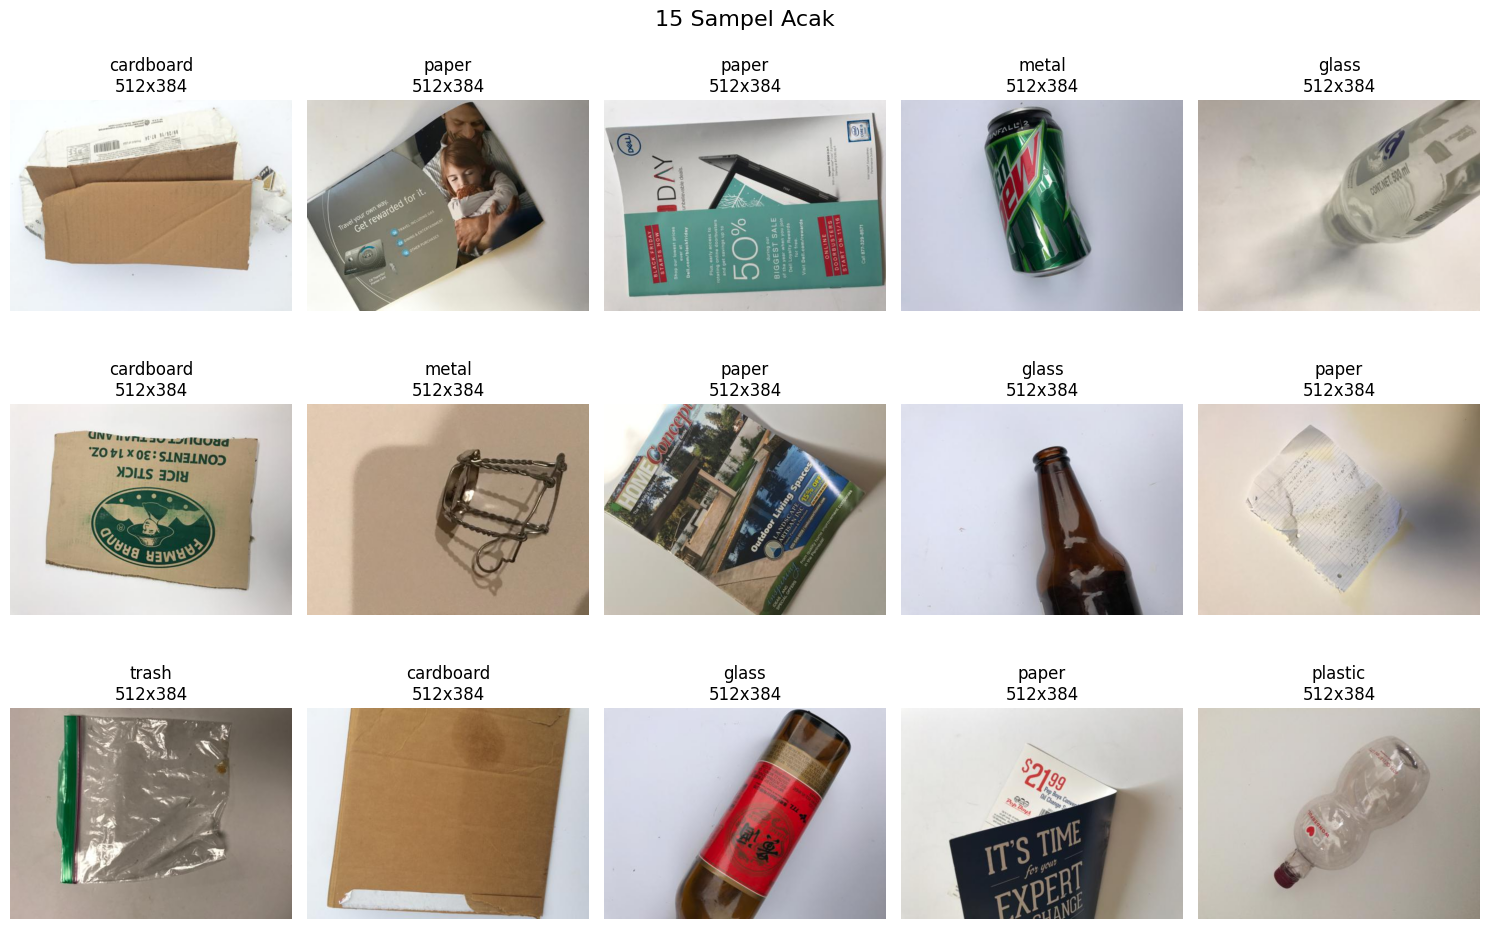

In [4]:
samples = random.sample(all_image_info, 15)
plt.figure(figsize=(15, 10))
for i, sample in enumerate(samples):
    img = cv2.imread(sample['path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3, 5, i+1)
    plt.imshow(img)
    plt.title(f"{sample['label']}\n{sample['width']}x{sample['height']}")
    plt.axis("off")
plt.suptitle("15 Sampel Acak", fontsize=16)
plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/sample.png')
plt.show()

In [5]:
widths = [d['width'] for d in all_image_info]
heights = [d['height'] for d in all_image_info]
formats = set([d['format'] for d in all_image_info])

In [6]:
print(f"Total gambar ditemukan: {len(all_image_info)}")
print(f"Format yang ditemukan: {formats}")
print(f"Rentang Resolusi: {min(widths)}x{min(heights)} s/d {max(widths)}x{max(heights)}")
print(f"Most Common Size: {max(set(widths), key=widths.count)}x{max(set(heights), key=heights.count)}")

Total gambar ditemukan: 2527
Format yang ditemukan: {'jpg'}
Rentang Resolusi: 512x384 s/d 512x384
Most Common Size: 512x384


### Statistic & Quality Data

In [7]:
pixel_values = []
class_counts = {label: 0 for label in labels}

In [8]:
for info in all_image_info:
    class_counts[info['label']] += 1
    img = cv2.imread(info['path'])
    if img is not None:
        avg_colors = np.mean(img, axis=(0, 1)) 
        pixel_values.append(avg_colors)

In [9]:
pixel_values = np.array(pixel_values)

In [10]:
temp_pixel_list = []
class_counts = {label: 0 for label in labels}
corrupted_files = 0
valid_images = 0

for info in all_image_info:
    class_counts[info['label']] += 1
    try:
        img = cv2.imread(info['path'])
        if img is not None:
            avg_colors = np.mean(img, axis=(0, 1)) 
            temp_pixel_list.append(avg_colors) 
            valid_images += 1
        else:
            corrupted_files += 1
    except Exception as e:
        corrupted_files += 1

pixel_values = np.array(temp_pixel_list)

print(f"Total Valid Images: {valid_images}")
print(f"Total Corrupted Files: {corrupted_files}")

Total Valid Images: 2527
Total Corrupted Files: 0


/tmp/ipykernel_92/618631155.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='magma')


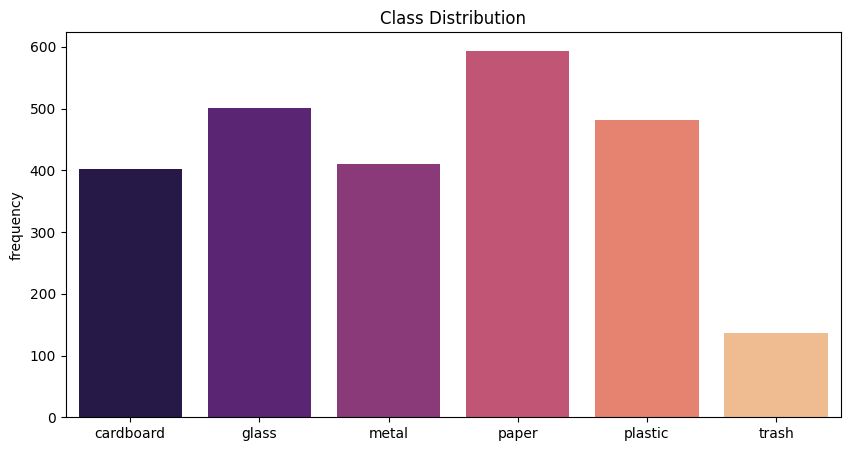

In [11]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='magma')
plt.title('Class Distribution')
plt.ylabel('frequency')
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/class_distribution.png')
plt.show()

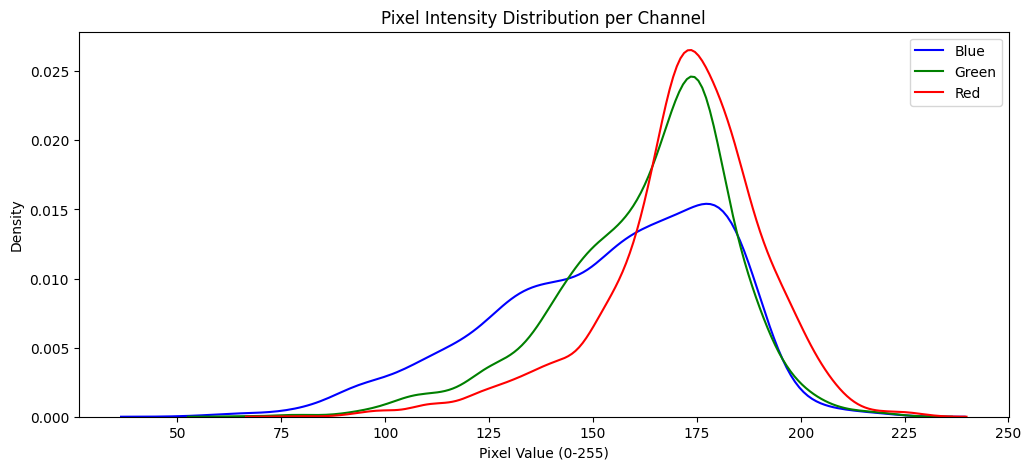

In [12]:
plt.figure(figsize=(12, 5))
colors = ['blue', 'green', 'red'] # OpenCV BGR
for i, col in enumerate(colors):
    sns.kdeplot(pixel_values[:, i], color=col, label=col.capitalize())
plt.title('Pixel Intensity Distribution per Channel')
plt.xlabel('Pixel Value (0-255)')
plt.legend()
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/pixel_intensity_density.png')
plt.show()

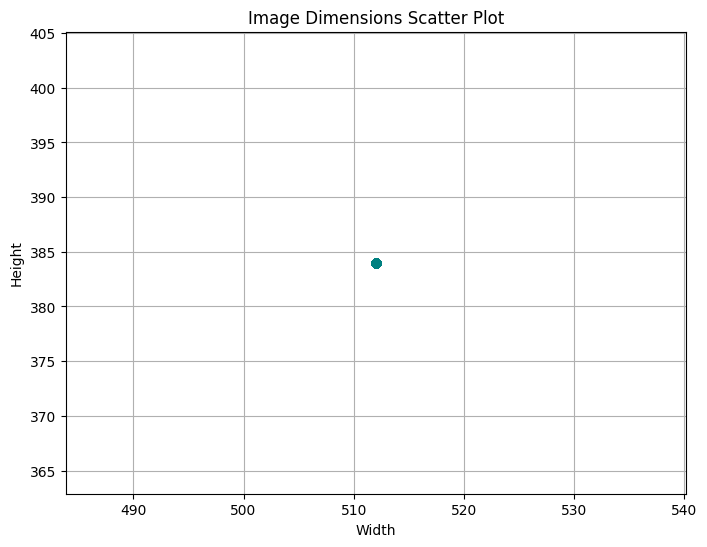

In [13]:
widths = [s['width'] for s in all_image_info]
heights = [s['height'] for s in all_image_info]
plt.figure(figsize=(8, 6))
plt.scatter(widths, heights, alpha=0.5, c='teal')
plt.title('Image Dimensions Scatter Plot')
plt.xlabel('Width')
plt.ylabel('Height')
plt.grid(True)
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/image_dimensions_scatter.png')
plt.show()

In [14]:
print("Hasil Statistik")
print(f"Mean RGB values: {np.mean(pixel_values, axis=0)}")
print(f"Std Dev RGB values: {np.std(pixel_values, axis=0)}")

Hasil Statistik
Mean RGB values: [154.23001766 163.14863228 171.6346233 ]
Std Dev RGB values: [27.53169073 20.95707819 19.49642154]


### Prepocessing

In [15]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [16]:
train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

Found 2024 images belonging to 6 classes.


In [17]:
test_generator = datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 503 images belonging to 6 classes.


In [18]:
sample_x, sample_y = next(train_generator)
print(f"Image batch shape    : {sample_x.shape}") # Harus (32, 224, 224, 3)
print(f"Label batch shape    : {sample_y.shape}") # Harus (32, 6)
print(f"Total Training Steps : {len(train_generator)}")
print(f"Total Testing Steps  : {len(test_generator)}")
print(f"Class Indices        : {train_generator.class_indices}")

Image batch shape    : (32, 224, 224, 3)
Label batch shape    : (32, 6)
Total Training Steps : 64
Total Testing Steps  : 16
Class Indices        : {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


### Baseline Model

In [19]:
INPUT_SHAPE = (IMG_SIZE[0], IMG_SIZE[1], 3) # (224, 224, 3)
NUM_CLASSES = len(train_generator.class_indices)

print(f"Input Shape: {INPUT_SHAPE}")
print(f"Output Classes: {NUM_CLASSES}")

Input Shape: (224, 224, 3)
Output Classes: 6


In [20]:
baseline_model = models.Sequential([
    # Layer 1: Convolution + Max Pooling
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=INPUT_SHAPE),
    layers.MaxPooling2D((2, 2)),
    
    # Layer 2: Convolution + Max Pooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Layer 3: Convolution + Max Pooling (3 Layer CNN)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten & Output
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-24 06:20:23.227111: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [21]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,768,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,825,670 (10.78 MB)

 Trainable params: 2,825,670 (10.78 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Karena kategori > 2
    metrics=['accuracy']
)

In [23]:
EPOCHS = 5

history_baseline = baseline_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=EPOCHS,
    validation_data=test_generator,
    validation_steps=len(test_generator),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.2910 - loss: 1.6633 - val_accuracy: 0.4175 - val_loss: 1.5509
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.5002 - loss: 1.2838 - val_accuracy: 0.4235 - val_loss: 1.3777
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.5491 - loss: 1.1604 - val_accuracy: 0.4672 - val_loss: 1.4267
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.6040 - loss: 1.0309 - val_accuracy: 0.4751 - val_loss: 1.3606
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.7026 - loss: 0.8256 - val_accuracy: 0.4871 - val_loss: 1.4473


In [24]:
# EPOCHS = 10

# history_baseline = baseline_model.fit(
#     train_generator,
#     steps_per_epoch=len(train_generator),
#     epochs=EPOCHS,
#     validation_data=test_generator,
#     validation_steps=len(test_generator),
#     verbose=1
# )

### Log Model

In [25]:
# def log_to_markdown(model_version, changes_made, history_object):
#     file_path = 'results_log.md'
#     date_now = datetime.date.today().strftime("%Y-%m-%d")

#     final_acc = history_object.history['val_accuracy'][-1]
#     final_loss = history_object.history['val_loss'][-1]

#     acc_value = f"{final_acc*100:.2f}%"
#     loss_value = f"{final_loss:.4f}"

#     if not os.path.exists(file_path):
#         with open(file_path, 'w') as f:
#             f.write("| Date | Model Version | Changes Made | Metric | Value |\n")
#             f.write("| :--- | :--- | :--- | :--- | :--- |\n")

#     with open(file_path, 'a') as f:
#         f.write(f"| {date_now} | {model_version} | {changes_made} | Accuracy (Val) | {acc_value} |\n")
#         f.write(f"| {date_now} | {model_version} | {changes_made} | Loss (Val) | {loss_value} |\n")
    
#     print(f"Berhasil mencatat {model_version} ke {file_path}!")

In [26]:
# log_to_markdown(
#     model_version="Baseline v1", 
#     changes_made="Initial CNN (3 layers, 5 epochs)", 
#     history_object=history_baseline
# )

### Improved Model

In [27]:
def build_transfer_model(base_model_class, model_name):
    base_model = base_model_class(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name=model_name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [28]:
model_mobile = build_transfer_model(MobileNetV2, "MobileNet_Experiment")
history_mobile = model_mobile.fit(train_generator, epochs=10, validation_data=test_generator)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 846ms/step - accuracy: 0.3127 - loss: 1.7900 - val_accuracy: 0.5408 - val_loss: 1.2130
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 823ms/step - accuracy: 0.6033 - loss: 1.0974 - val_accuracy: 0.6243 - val_loss: 0.9828
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 822ms/step - accuracy: 0.7106 - loss: 0.8428 - val_accuracy: 0.6521 - val_loss: 0.9073
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 814ms/step - accuracy: 0.7255 - loss: 0.7341 - val_accuracy: 0.7078 - val_loss: 0.8146
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 805ms/step - accuracy: 0.7557 - loss: 0.6551 - val_accuracy: 0.6879 - val_loss: 0.7867
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 51s 798ms/step - accuracy: 0.8090 - loss: 0.5730 - val_accuracy: 0.7177 - val_loss: 0.7456
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 51s 799ms/step - accuracy: 0.8088 - loss: 0.5393 - val_accuracy: 0.7137 - val_loss: 0.7154
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 807ms/

In [29]:
# log_to_markdown("MobileNetV2 1", "Transfer Learning MobileNetV2, 10 Epochs", history_mobile)

In [30]:
# model_vgg = build_transfer_model(VGG16, "VGG16_V1")
# history_vgg = model_vgg.fit(train_generator, epochs=10, validation_data=test_generator)

In [31]:
# log_to_markdown("VGG16 1", "Transfer Learning VGG16, 10 Epochs", history_vgg)

In [32]:
# model_resnet = build_transfer_model(ResNet50, "ResNet50_Experiment")
# history_resnet = model_resnet.fit(train_generator, epochs=10, validation_data=test_generator)

In [33]:
# log_to_markdown("ResNet50 1", "Transfer Learning ResNet50, 10 Epochs", history_resnet)

In [34]:
# base_model = model_mobile.layers[0]
# base_model.trainable = True

# fine_tune_at = 100
# for layer in base_model.layers[:fine_tune_at]:
#     layer.trainable = False

# # Pakai model_mobile karena itu variabel yang kamu punya
# model_mobile.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# history_finetune = model_mobile.fit(
#     train_generator,
#     epochs=20,
#     validation_data=test_generator,
#     verbose=1
# )

In [35]:
# log_to_markdown(
#     model_version="MobileNetV2 Fine-Tuned", 
#     changes_made="Unfreeze from layer 100, LR=1e-5, 20 Epochs", 
#     history_object=history_finetune
# )

In [36]:
base_model_ultimate = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model_ultimate.trainable = True
fine_tune_at = 100
for layer in base_model_ultimate.layers[:fine_tune_at]:
    layer.trainable = False

model_ultimate = models.Sequential([
    base_model_ultimate,
    layers.GlobalAveragePooling2D(),
    
    layers.Dropout(0.5), # Buang 50% koneksi acak (sebelumnya cuma 30%)
    
    layers.Dense(256, activation='relu'), # Tambah neuron
    layers.BatchNormalization(),       # Stabilisasi training
    layers.Dropout(0.3),             # Tambah Dropout
    
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="Ultimate_Anti_Overfitting")

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-4, # Kecepatan awal stabil
    decay_steps=1000,           # Setiap 1000 step
    decay_rate=0.9             # Kecepatan berkurang 10%
)

model_ultimate.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
history_ultimate = model_ultimate.fit(
    train_generator,
    epochs=30,
    validation_data=test_generator,
    verbose=1
)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.3014 - loss: 2.1394 - val_accuracy: 0.5507 - val_loss: 1.2313
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.6929 - loss: 0.8915 - val_accuracy: 0.5527 - val_loss: 1.3485
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.8165 - loss: 0.5564 - val_accuracy: 0.6064 - val_loss: 1.2441
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.8612 - loss: 0.4007 - val_accuracy: 0.5408 - val_loss: 1.6636
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9079 - loss: 0.2649 - val_accuracy: 0.5706 - val_loss: 1.6935
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9273 - loss: 0.2073 - val_accuracy: 0.6024 - val_loss: 1.5465
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9382 - loss: 0.1697 - val_accuracy: 0.6004 - val_loss: 1.5541
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9714 - loss: 0.1121 - val_accuracy: 0.6620 - val_loss:

In [38]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2, 
    horizontal_flip=True,
    fill_mode='nearest'
)

# Run ulang generator
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 2527 images belonging to 6 classes.


In [39]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

history_final = model_ultimate.fit(
    train_generator,
    epochs=15, 
    validation_data=test_generator,
    callbacks=[callback],
    verbose=1
)

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.8646 - loss: 0.5184 - val_accuracy: 0.8867 - val_loss: 0.3786
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.8855 - loss: 0.3395 - val_accuracy: 0.9105 - val_loss: 0.2883
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.9076 - loss: 0.2901 - val_accuracy: 0.8907 - val_loss: 0.2894
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.9238 - loss: 0.2462 - val_accuracy: 0.8907 - val_loss: 0.3309
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.9378 - loss: 0.1947 - val_accuracy: 0.8748 - val_loss: 0.4397
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.9497 - loss: 0.1347 - val_accuracy: 0.9264 - val_loss: 0.1720
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.9610 - loss: 0.1313 - val_accuracy: 0.9742 - val_loss: 0.0832
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.9411 - loss: 0.1566 - val_accuracy: 0.9781 - v

In [40]:
# log_to_markdown(
#     model_version="MobileNetV2 EarlyStop", 
#     changes_made="Aggressive Augmentation + Early Stopping", 
#     history_object=history_final
# )

In [41]:
def predict_trash(img_path):
    # Load & Preprocess Gambar
    img = utils.load_img(img_path, target_size=(224, 224))
    img_array = utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.
    
    prediction = model_ultimate.predict(img_array)
    
    predicted_label = labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    # Plot
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Prediksi: {predicted_label} ({confidence:.2f}%)")
    plt.axis('off')

    # Save File
    nama_file_asli = os.path.basename(img_path)
    nama_bersih = os.path.splitext(nama_file_asli)[0]
    
    os.makedirs('outputs', exist_ok=True)
    save_path = f'outputs/hasil_{nama_bersih}.png'
    
    plt.savefig(save_path)
    plt.show()

    print(f"✅ Selesai! Hasil prediksi disimpan ke: {save_path}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


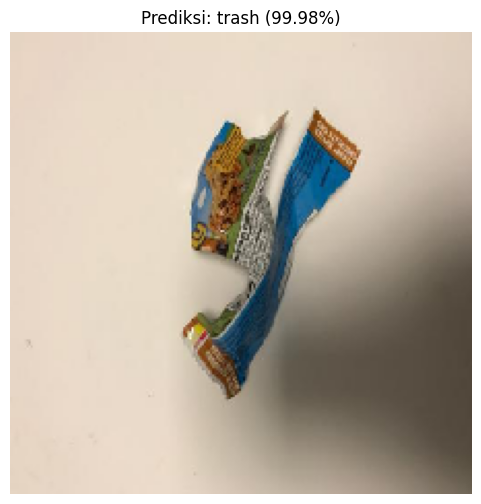

✅ Selesai! Hasil prediksi disimpan ke: outputs/hasil_trash19.png


In [42]:
# Tes Sampah
predict_trash(os.path.join(base_dir, 'trash', 'trash19.jpg'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


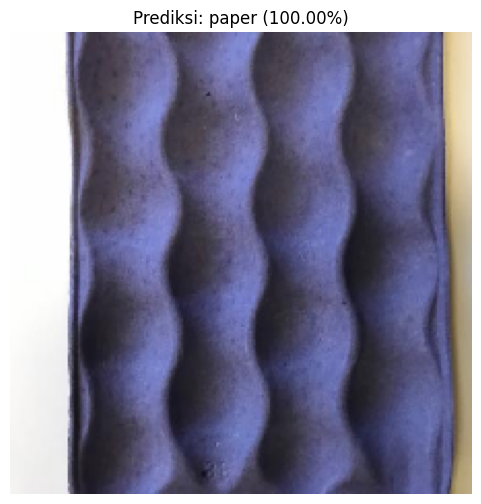

✅ Selesai! Hasil prediksi disimpan ke: outputs/hasil_paper10.png


In [43]:
# Tes Kertas
predict_trash(os.path.join(base_dir, 'paper', 'paper10.jpg'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


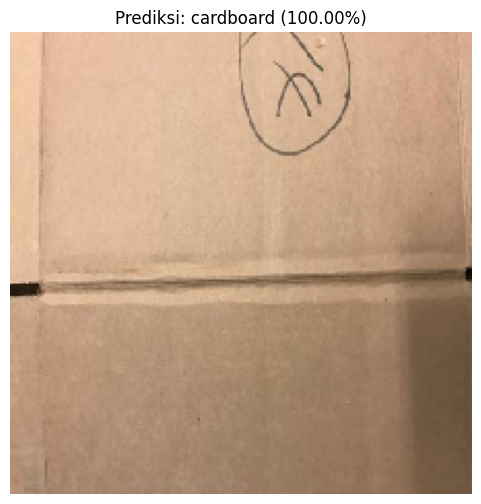

✅ Selesai! Hasil prediksi disimpan ke: outputs/hasil_cardboard1.png


In [44]:
# Tes Kardus
predict_trash(os.path.join(base_dir, 'cardboard', 'cardboard1.jpg'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


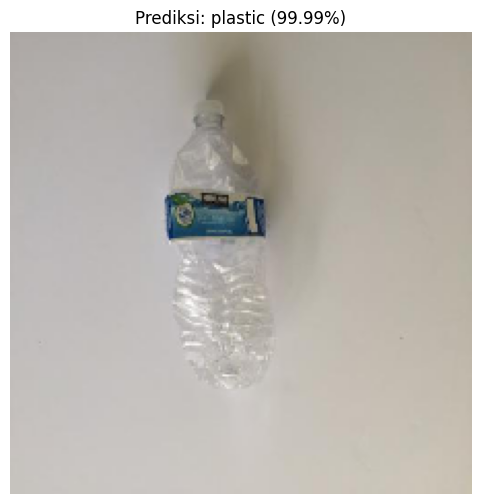

✅ Selesai! Hasil prediksi disimpan ke: outputs/hasil_plastic5.png


In [45]:
# Tes Plastik
predict_trash(os.path.join(base_dir, 'plastic', 'plastic5.jpg'))

### Visualization Results

In [46]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training Acc')
    plt.plot(epochs, val_acc, 'r', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    os.makedirs('outputs', exist_ok=True)
    plt.savefig('outputs/training_history.png')
    plt.show()

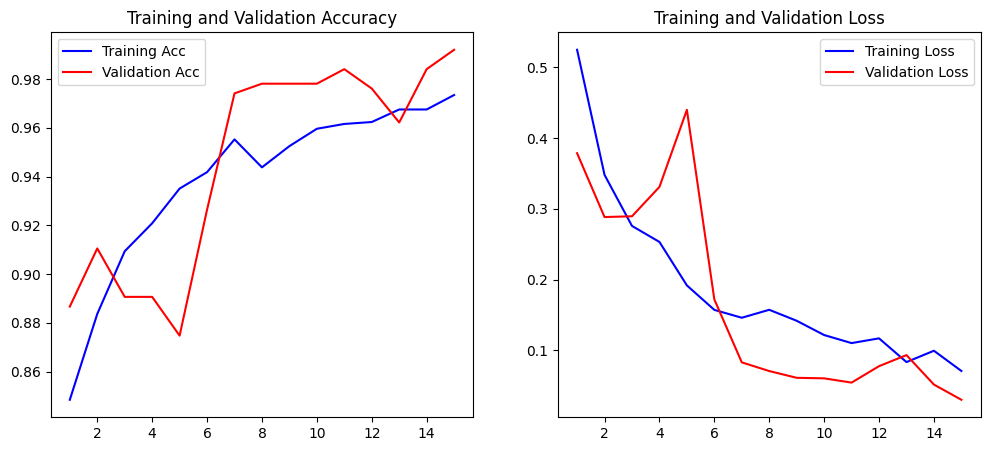

In [47]:
plot_history(history_final)

In [48]:
labels_plot = list(train_generator.class_indices.keys())

def plot_cm(model, test_ds):

    test_ds.shuffle = False
    test_ds.reset()

    y_true = test_ds.classes

    preds = model.predict(test_ds)
    y_pred = np.argmax(preds, axis=1)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels_plot, yticklabels=labels_plot)
    plt.xlabel('Prediksi (Model)')
    plt.ylabel('Kenyataan (Label Asli)')
    plt.title('Confusion Matrix - Ujian Akhir Model')

    os.makedirs('outputs', exist_ok=True)
    plt.savefig('outputs/confusion_matrix.png')
    plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 779ms/step


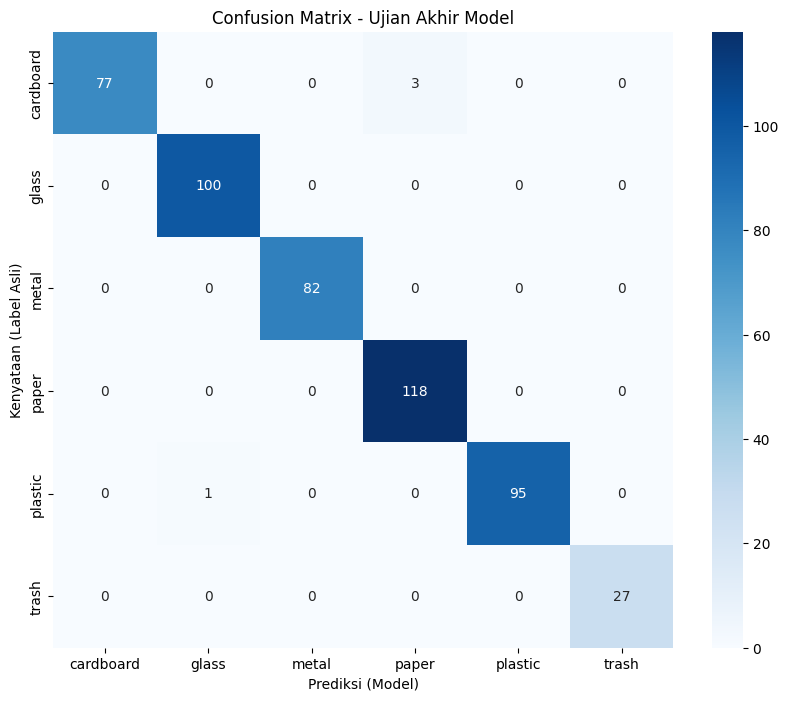

In [49]:
plot_cm(model_ultimate, test_generator)

In [50]:
another_dir = '/kaggle/input/datasets/zlatan599/garbage-dataset-classification/Garbage_Dataset_Classification/images'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


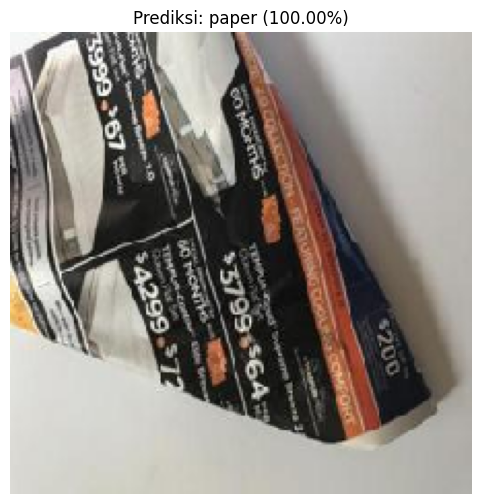

✅ Selesai! Hasil prediksi disimpan ke: outputs/hasil_paper_00261.png


In [51]:
predict_trash(os.path.join(another_dir, 'paper', 'paper_00261.jpg'))

In [52]:
model_ultimate.save('model_v1.h5')
model_ultimate.save_weights('model.weights.h5')
model_ultimate.save('model_v1.keras')

print("Selesai! Model telah tersimpan.")

Selesai! Model telah tersimpan.
